# Mô hình dự đoán `is_canceled` — LightGBM v2

Phiên bản **v2** dùng **LightGBM** thay Random Forest, **giữ nguyên toàn bộ feature** từ v1.2:

### Nhóm 1 — Mức độ cam kết tài chính (Financial Commitment)
| Biến | Công thức |
|------|----------|
| `total_guests` | `adults + children + babies` |
| `price_per_person` | `adr / total_guests` |
| `is_family` | 1 nếu `children > 0` hoặc `babies > 0`, ngược lại 0 |

### Nhóm 2 — Cấu trúc chuyến đi (Trip Structure)
| Biến | Công thức |
|------|----------|
| `total_nights` | `stays_in_weekend_nights + stays_in_week_nights` |
| `lead_time_per_night` | `lead_time / total_nights` |

### Nhóm 3 — Lịch sử và uy tín (Trust & History)
| Biến | Công thức |
|------|----------|
| `history_cancel_rate` | `previous_cancellations / (previous_cancellations + previous_bookings_not_canceled)` |

### Nhóm 4 — Lịch & mùa (Calendar & Seasonality)
| Biến | Công thức |
|------|----------|
| `is_weekend_only` | 1 nếu chỉ ở cuối tuần (`weekend_nights > 0` và `week_nights == 0`) |
| `arrival_month_mapped` | Tháng đến ánh xạ số 1–12 (Jan→1 … Dec→12) |

Giữ nguyên 6 biến phân loại v1.1 + `lead_time`, `total_of_special_requests`. Thay `previous_cancellations` bằng `history_cancel_rate`.

**Ngưỡng dự đoán:** `P(hủy) >= 0.35` → dự đoán **Hủy** (so sánh công bằng với RF v1.2).

**Nguyên tắc chống Data Leakage:**
1. Chỉ đọc feature + target cần thiết — **không** nạp `reservation_status`, `revenue`, `Occupancy_Rate`, `RevPAR`, ...
2. Feature engineering chỉ dùng thông tin có tại thời điểm đặt phòng.
3. `train_test_split` **trước** mọi bước tiền xử lý mã hóa.
4. `OneHotEncoder` chỉ `fit` trên tập train (qua `Pipeline` + `ColumnTransformer`).


In [33]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
TEST_SIZE = 0.2
DATA_BASENAME = "hotel_bookings"
VERSION_PATTERN = re.compile(rf"^{DATA_BASENAME}_v(\d+)\.csv$", re.IGNORECASE)

LEAKAGE_COLUMNS = {
    "reservation_status",
    "reservation_status_date",
    "revenue",
    "Occupancy_Rate",
    "RevPAR",
}

PREDICTION_THRESHOLD = 0.35

MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
MONTH_TO_NUM = {month: i + 1 for i, month in enumerate(MONTH_ORDER)}

CATEGORICAL_FEATURES = [
    "deposit_type",
    "market_segment",
    "country",
    "distribution_channel",
    "customer_type",
    "hotel",
]

RAW_COLUMNS_FOR_ENGINEERING = [
    "adults", "children", "babies", "adr",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "previous_bookings_not_canceled", "arrival_date_month",
]

NUMERIC_FEATURES = [
    "lead_time",
    "total_of_special_requests",
    "total_guests",
    "price_per_person",
    "is_family",
    "total_nights",
    "lead_time_per_night",
    "history_cancel_rate",
    "is_weekend_only",
    "arrival_month_mapped",
]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES
TARGET_COLUMN = "is_canceled"


def _data_search_roots() -> list[Path]:
    notebook_dir = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
    search_roots = [
        notebook_dir / "data",
        notebook_dir,
        notebook_dir.parent / "data",
        notebook_dir.parent,
        notebook_dir.parent.parent,
        Path.cwd() / "data",
        Path.cwd(),
    ]
    path = Path.cwd()
    for _ in range(6):
        search_roots.extend([path / "data", path])
        path = path.parent

    seen, roots = set(), []
    for root in search_roots:
        try:
            root = root.resolve()
        except OSError:
            continue
        if root not in seen:
            seen.add(root)
            roots.append(root)
    return roots


def find_latest_versioned_data_file() -> Path:
    candidates: list[tuple[int, Path]] = []
    for root in _data_search_roots():
        if not root.is_dir():
            continue
        for file_path in root.glob(f"{DATA_BASENAME}_v*.csv"):
            if "test" in file_path.name.lower():
                continue
            match = VERSION_PATTERN.match(file_path.name)
            if match:
                candidates.append((int(match.group(1)), file_path.resolve()))

    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy file '{DATA_BASENAME}_v*.csv'")

    latest_version, latest_path = max(candidates, key=lambda item: item[0])
    print(f"Chọn file v{latest_version} mới nhất: {latest_path.name}")
    return latest_path


csv_path = find_latest_versioned_data_file()
print(f"Đang đọc: {csv_path}")

read_columns = list(
    dict.fromkeys(
        CATEGORICAL_FEATURES
        + ["lead_time", "total_of_special_requests"]
        + RAW_COLUMNS_FOR_ENGINEERING
        + ["previous_cancellations"]
        + [TARGET_COLUMN]
    )
)
df = pd.read_csv(csv_path, usecols=read_columns)

print(f"Số booking: {len(df):,}")
print(f"Tỷ lệ hủy: {df[TARGET_COLUMN].mean() * 100:.2f}%")
print(f"\nCột leakage đã loại: {sorted(LEAKAGE_COLUMNS)}")
df.head()


Chọn file v5 mới nhất: hotel_bookings_v5.csv
Đang đọc: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
Số booking: 82,811
Tỷ lệ hủy: 28.12%

Cột leakage đã loại: ['Occupancy_Rate', 'RevPAR', 'reservation_status', 'reservation_status_date', 'revenue']


,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,deposit_type,customer_type,adr,total_of_special_requests
0,Resort Hotel,0,342,July,0,0,2,0,0,PRT,Direct,Direct,0,0,No Deposit,Transient,0.0,0
1,Resort Hotel,0,737,July,0,0,2,0,0,PRT,Direct,Direct,0,0,No Deposit,Transient,0.0,0
2,Resort Hotel,0,7,July,0,1,1,0,0,GBR,Direct,Direct,0,0,No Deposit,Transient,75.0,0
3,Resort Hotel,0,13,July,0,1,1,0,0,GBR,Corporate,Corporate,0,0,No Deposit,Transient,75.0,0
4,Resort Hotel,0,14,July,0,2,2,0,0,GBR,Online TA,TA/TO,0,0,No Deposit,Transient,98.0,1


## 1. Feature engineering & kiểm tra dữ liệu

Tạo 9 biến engineered từ cột thô, xử lý edge case (chia cho 0), rồi chuẩn bị ma trận `X`.


In [34]:
def engineer_features(raw: pd.DataFrame) -> pd.DataFrame:
    """Tạo biến engineered v1.2 từ cột thô (thông tin có tại thời điểm đặt)."""
    out = raw.copy()

    out["children"] = out["children"].fillna(0)
    out["total_guests"] = out["adults"] + out["children"] + out["babies"]
    out["total_guests"] = out["total_guests"].clip(lower=1)

    out["price_per_person"] = out["adr"] / out["total_guests"]
    out["is_family"] = (
        (out["children"] > 0) | (out["babies"] > 0)
    ).astype(int)

    out["total_nights"] = (
        out["stays_in_weekend_nights"] + out["stays_in_week_nights"]
    )
    out["lead_time_per_night"] = out["lead_time"] / out["total_nights"].clip(lower=1)

    prior_total = (
        out["previous_cancellations"] + out["previous_bookings_not_canceled"]
    )
    out["history_cancel_rate"] = np.where(
        prior_total > 0,
        out["previous_cancellations"] / prior_total,
        0.0,
    )

    out["is_weekend_only"] = (
        (out["stays_in_weekend_nights"] > 0) & (out["stays_in_week_nights"] == 0)
    ).astype(int)

    out["arrival_month_mapped"] = (
        out["arrival_date_month"].map(MONTH_TO_NUM).fillna(0).astype(int)
    )

    return out


print("=== Missing values (cột thô) ===")
print(df[RAW_COLUMNS_FOR_ENGINEERING + ["previous_cancellations"]].isna().sum())

engineered_df = engineer_features(df)

print("\n=== Biến engineered (describe) ===")
engineered_cols = [
    "total_guests", "price_per_person", "is_family",
    "total_nights", "lead_time_per_night", "history_cancel_rate",
    "is_weekend_only", "arrival_month_mapped",
]
display(engineered_df[engineered_cols].describe().T)

model_df = engineered_df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
model_df["country"] = model_df["country"].fillna("Unknown").astype(str)
for col in CATEGORICAL_FEATURES:
    model_df[col] = model_df[col].astype(str)

int_like = [
    "lead_time", "total_of_special_requests", "total_guests", "is_family",
    "total_nights", "is_weekend_only", "arrival_month_mapped",
]
float_like = ["price_per_person", "lead_time_per_night", "history_cancel_rate"]
for col in int_like:
    model_df[col] = model_df[col].fillna(0).astype(int)
for col in float_like:
    model_df[col] = model_df[col].fillna(0.0).astype(float)

X = model_df[FEATURE_COLUMNS]
y = model_df[TARGET_COLUMN].astype(int)

print(f"\nKích thước X: {X.shape} ({len(CATEGORICAL_FEATURES)} phân loại + {len(NUMERIC_FEATURES)} số)")
print(f"Phân bố y: {y.value_counts().to_dict()}")


=== Missing values (cột thô) ===
adults                            0
children                          0
babies                            0
adr                               0
stays_in_weekend_nights           0
stays_in_week_nights              0
previous_bookings_not_canceled    0
arrival_date_month                0
previous_cancellations            0
dtype: int64

=== Biến engineered (describe) ===


,count,mean,std,min,25%,50%,75%,max
total_guests,82811.0,2.044861,0.797066,1.00,2.00,2.000000,2.0,55.0
price_per_person,82811.0,55.694585,29.939480,-3.19,38.00,50.000000,67.5,2700.0
is_family,82811.0,0.108585,0.311119,0.00,0.00,0.000000,0.0,1.0
total_nights,82811.0,3.674705,2.786843,0.00,2.00,3.000000,5.0,69.0
lead_time_per_night,82811.0,25.199919,36.216372,0.00,4.25,14.428571,32.0,737.0
history_cancel_rate,82811.0,0.013364,0.110402,0.00,0.00,0.000000,0.0,1.0
is_weekend_only,82811.0,0.062902,0.242789,0.00,0.00,0.000000,0.0,1.0
arrival_month_mapped,82811.0,6.467390,3.088011,1.00,4.00,7.000000,9.0,12.0



Kích thước X: (82811, 16) (6 phân loại + 10 số)
Phân bố y: {0: 59527, 1: 23284}


## 2. Train / Test split (trước khi mã hóa)

Tách dữ liệu **trước** mọi bước fit encoder để tránh leakage từ tập test vào quá trình học category.


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Tỷ lệ hủy train: {y_train.mean() * 100:.2f}%")
print(f"Tỷ lệ hủy test:  {y_test.mean() * 100:.2f}%")


Train: 66,248 | Test: 16,563
Tỷ lệ hủy train: 28.12%
Tỷ lệ hủy test:  28.12%


## 3. Pipeline: One-Hot + biến số → LightGBM

- **OneHotEncoder** cho biến phân loại; biến số đi **passthrough**.
- `min_frequency=5`: gộp category hiếm thành `infrequent` — chỉ học từ train.
- **LightGBM**: gradient boosting trên cây, `class_weight='balanced'` xử lý mất cân bằng lớp.
- Dự đoán nhị phân dùng ngưỡng **0,35**: `y_pred = (P(hủy) >= 0.35)`.


In [36]:
BASELINE_LGBM_PARAMS = {
    "n_estimators": 300,
    "max_depth": 12,
    "min_child_samples": 20,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

RUN_TUNING = True
TUNING_CV = 3
N_OPTUNA_TRIALS = 35


def make_lgbm_pipeline(**classifier_kwargs) -> Pipeline:
    """Tạo Pipeline One-Hot + LightGBM với tham số classifier tùy chỉnh."""
    cat_encoder = OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=5,
        sparse_output=False,
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", cat_encoder, CATEGORICAL_FEATURES),
            ("num", "passthrough", NUMERIC_FEATURES),
        ],
        remainder="drop",
    )
    params = {**BASELINE_LGBM_PARAMS, **classifier_kwargs}
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LGBMClassifier(**params)),
        ]
    )


def metrics_at_threshold(y_true, y_proba, threshold=PREDICTION_THRESHOLD) -> dict:
    y_hat = (y_proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "recall_huy": recall_score(y_true, y_hat, pos_label=1),
        "precision_huy": precision_score(y_true, y_hat, pos_label=1),
        "f1_huy": f1_score(y_true, y_hat, pos_label=1),
        "accuracy": (y_hat == y_true).mean(),
    }


lgbm_baseline_pipeline = make_lgbm_pipeline()
lgbm_pipeline = lgbm_baseline_pipeline
lgbm_baseline_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 3b. Tinh chỉnh hyperparameter (GridSearchCV + Optuna)

Tìm bộ tham số tốt nhất **chỉ trên tập train** (CV), tránh leakage từ test.

- **GridSearchCV:** lưới tham số cố định, tối ưu `roc_auc`.
- **Optuna (TPE):** tìm kiếm rộng hơn (`num_leaves`, `reg_alpha`, `reg_lambda`, ...).
- Chọn phương án có **CV ROC-AUC cao hơn** → gán vào `lgbm_pipeline` cho các bước sau.



In [37]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

try:
    import optuna
    from optuna.samplers import TPESampler
except ImportError:
    raise ImportError("Cài optuna: pip install optuna")

cv_tune = StratifiedKFold(n_splits=TUNING_CV, shuffle=True, random_state=RANDOM_STATE)

if not RUN_TUNING:
    best_params = BASELINE_LGBM_PARAMS.copy()
    tuning_source = "baseline (RUN_TUNING=False)"
    grid_cv_auc = optuna_cv_auc = None
    print("Bỏ qua tuning — dùng BASELINE_LGBM_PARAMS.")
else:
    print("=== GridSearchCV (scoring=roc_auc) ===")
    param_grid = {
        "classifier__n_estimators": [250, 400],
        "classifier__max_depth": [10, 14],
        "classifier__min_child_samples": [15, 30],
        "classifier__learning_rate": [0.03, 0.06],
        "classifier__subsample": [0.75, 0.85],
        "classifier__colsample_bytree": [0.75, 0.85],
    }
    grid_search = GridSearchCV(
        estimator=make_lgbm_pipeline(),
        param_grid=param_grid,
        cv=cv_tune,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)
    grid_cv_auc = grid_search.best_score_
    grid_best_params = {
        k.replace("classifier__", ""): v for k, v in grid_search.best_params_.items()
    }
    print(f"GridSearch best CV ROC-AUC: {grid_cv_auc:.4f}")
    print("GridSearch best params:", grid_best_params)

    print(f"\n=== Optuna TPE ({N_OPTUNA_TRIALS} trials, scoring=roc_auc) ===")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def optuna_objective(trial: optuna.Trial) -> float:
        trial_params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 500, step=50),
            "max_depth": trial.suggest_int("max_depth", 6, 16),
            "num_leaves": trial.suggest_int("num_leaves", 20, 80),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 50, step=5),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 0.95),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.95),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        }
        pipe = make_lgbm_pipeline(**trial_params)
        scores = cross_val_score(
            pipe, X_train, y_train, cv=cv_tune, scoring="roc_auc", n_jobs=-1,
        )
        return float(scores.mean())

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)
    optuna_cv_auc = study.best_value
    optuna_best_params = study.best_params
    print(f"Optuna best CV ROC-AUC: {optuna_cv_auc:.4f}")
    print("Optuna best params:", optuna_best_params)

    if optuna_cv_auc >= grid_cv_auc:
        best_params = {
            **optuna_best_params,
            "class_weight": "balanced",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
            "verbose": -1,
        }
        tuning_source = "Optuna"
    else:
        best_params = {
            **grid_best_params,
            "class_weight": "balanced",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
            "verbose": -1,
        }
        tuning_source = "GridSearchCV"

    print(f"\n>>> Chọn bộ tham số từ: {tuning_source}")

lgbm_pipeline = make_lgbm_pipeline(**best_params)

compare_cv = pd.DataFrame(
    {
        "phương_pháp": ["Baseline", "GridSearchCV", "Optuna"],
        "cv_roc_auc": [
            cross_val_score(
                lgbm_baseline_pipeline, X_train, y_train,
                cv=cv_tune, scoring="roc_auc", n_jobs=-1,
            ).mean(),
            grid_cv_auc,
            optuna_cv_auc,
        ],
    }
)
if not RUN_TUNING:
    compare_cv = compare_cv.iloc[[0]]
compare_cv = compare_cv.dropna(subset=["cv_roc_auc"]).round(4)
print("\n=== So sánh CV ROC-AUC (cùng fold) ===")
display(compare_cv)

print("\n=== Best params (dùng cho lgbm_pipeline) ===")
display(pd.Series(best_params, name="value"))


=== GridSearchCV (scoring=roc_auc) ===
Fitting 3 folds for each of 64 candidates, totalling 192 fits
GridSearch best CV ROC-AUC: 0.8628
GridSearch best params: {'colsample_bytree': 0.75, 'learning_rate': 0.06, 'max_depth': 14, 'min_child_samples': 15, 'n_estimators': 400, 'subsample': 0.75}

=== Optuna TPE (35 trials, scoring=roc_auc) ===
Optuna best CV ROC-AUC: 0.8653
Optuna best params: {'n_estimators': 250, 'max_depth': 15, 'num_leaves': 61, 'min_child_samples': 35, 'learning_rate': 0.06327088846969782, 'subsample': 0.7957118696489107, 'colsample_bytree': 0.6332771647068834, 'reg_alpha': 0.008189179973637264, 'reg_lambda': 3.265450956311304}

>>> Chọn bộ tham số từ: Optuna

=== So sánh CV ROC-AUC (cùng fold) ===


,phương_pháp,cv_roc_auc
0,Baseline,0.8619
1,GridSearchCV,0.8628
2,Optuna,0.8653



=== Best params (dùng cho lgbm_pipeline) ===


n_estimators              250
max_depth                  15
num_leaves                 61
min_child_samples          35
learning_rate        0.063271
subsample            0.795712
colsample_bytree     0.633277
reg_alpha            0.008189
reg_lambda           3.265451
class_weight         balanced
random_state               42
n_jobs                     -1
verbose                    -1
Name: value, dtype: object

## 4. Huấn luyện & đánh giá


In [38]:
print("Huấn luyện baseline...")
lgbm_baseline_pipeline.fit(X_train, y_train)
baseline_proba = lgbm_baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_metrics = metrics_at_threshold(y_test, baseline_proba)

print("Huấn luyện mô hình đã tune...")
lgbm_pipeline.fit(X_train, y_train)
y_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= PREDICTION_THRESHOLD).astype(int)
tuned_metrics = metrics_at_threshold(y_test, y_proba)

compare_test = pd.DataFrame(
    [baseline_metrics, tuned_metrics],
    index=["Baseline", f"Tuned ({tuning_source})"],
).round(4)
print(f"\n=== So sánh Test @ ngưỡng {PREDICTION_THRESHOLD} ===")
display(compare_test)

print(f"\n=== Classification Report — Tuned ({tuning_source}) ===")
print(classification_report(y_test, y_pred, target_names=["Không hủy", "Hủy"]))

roc_auc = tuned_metrics["roc_auc"]
print(f"ROC-AUC (test, tuned): {roc_auc:.4f}")

cv_scores = cross_val_score(
    lgbm_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)
print(f"CV ROC-AUC 5-fold (tuned, train): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

y_pred_default = (y_proba >= 0.5).astype(int)
print(f"\n--- Ngưỡng 0.50 vs {PREDICTION_THRESHOLD} (tuned) ---")
print(f"F1 @ 0.50: {f1_score(y_test, y_pred_default, pos_label=1):.4f}")
print(f"F1 @ {PREDICTION_THRESHOLD}: {f1_score(y_test, y_pred, pos_label=1):.4f}")


Huấn luyện baseline...
Huấn luyện mô hình đã tune...

=== So sánh Test @ ngưỡng 0.35 ===


,roc_auc,recall_huy,precision_huy,f1_huy,accuracy
Baseline,0.8666,0.9049,0.4799,0.6272,0.6975
Tuned (Optuna),0.8712,0.8993,0.4917,0.6357,0.7103



=== Classification Report — Tuned (Optuna) ===
              precision    recall  f1-score   support

   Không hủy       0.94      0.64      0.76     11906
         Hủy       0.49      0.90      0.64      4657

    accuracy                           0.71     16563
   macro avg       0.72      0.77      0.70     16563
weighted avg       0.82      0.71      0.72     16563

ROC-AUC (test, tuned): 0.8712
CV ROC-AUC 5-fold (tuned, train): 0.8668 ± 0.0037

--- Ngưỡng 0.50 vs 0.35 (tuned) ---
F1 @ 0.50: 0.6763
F1 @ 0.35: 0.6357


## 5. Ma trận nhầm lẫn & ROC Curve


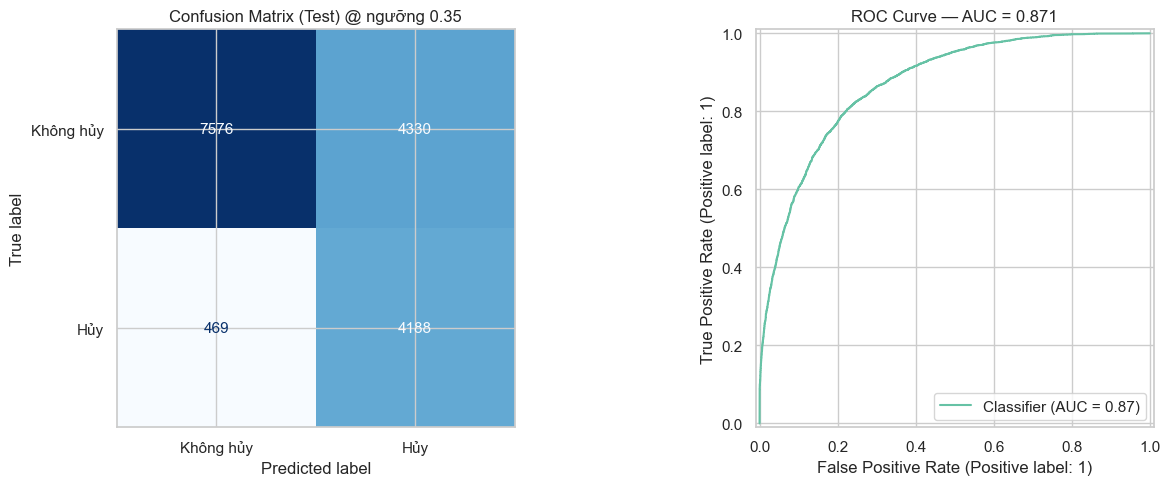

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Không hủy", "Hủy"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"Confusion Matrix (Test) @ ngưỡng {PREDICTION_THRESHOLD}")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"ROC Curve — AUC = {roc_auc:.3f}")

plt.tight_layout()
plt.show()


## 6. Phân phối xác suất dự đoán (Prediction Probability Distribution)

So sánh phân phối `P(hủy)` giữa booking **thực sự hủy** và **không hủy** trên tập test.

**Quy ước màu:** teal = Không hủy, orange = Hủy; đường nét = ngưỡng **0,35** (v1.1/v1.2).


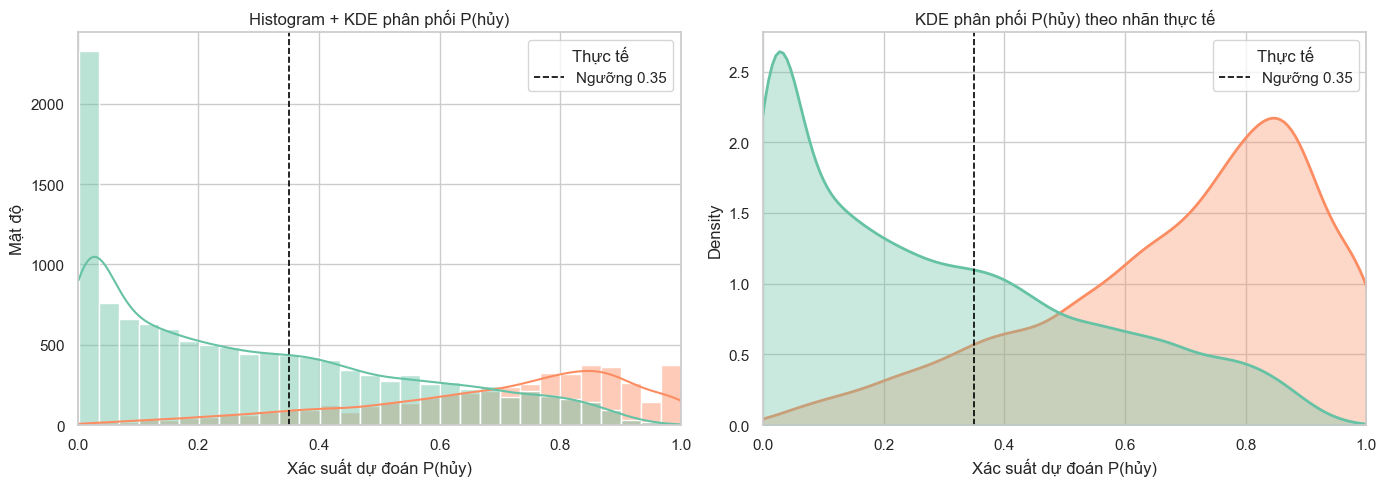

=== Thống kê P(hủy) theo nhãn thực tế (test) ===


,n,mean,median,std
actual,,,,
Không hủy,11906,0.2885,0.2314,0.2497
Hủy,4657,0.6909,0.7454,0.2267


In [40]:
proba_df = pd.DataFrame(
    {
        "probability": y_proba,
        "actual": np.where(y_test == 1, "Hủy", "Không hủy"),
    }
)

LABEL_ORDER = ["Không hủy", "Hủy"]
LABEL_PALETTE = {"Không hủy": "#66c2a5", "Hủy": "#fc8d62"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=proba_df,
    x="probability",
    hue="actual",
    hue_order=LABEL_ORDER,
    palette=LABEL_PALETTE,
    bins=30,
    kde=True,
    common_norm=False,
    alpha=0.45,
    ax=axes[0],
)
axes[0].axvline(PREDICTION_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"Ngưỡng {PREDICTION_THRESHOLD}")
axes[0].set_xlabel("Xác suất dự đoán P(hủy)")
axes[0].set_ylabel("Mật độ")
axes[0].set_title("Histogram + KDE phân phối P(hủy)")
axes[0].legend(title="Thực tế")
axes[0].set_xlim(0, 1)

sns.kdeplot(
    data=proba_df,
    x="probability",
    hue="actual",
    hue_order=LABEL_ORDER,
    palette=LABEL_PALETTE,
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=2,
    ax=axes[1],
)
axes[1].axvline(PREDICTION_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"Ngưỡng {PREDICTION_THRESHOLD}")
axes[1].set_xlabel("Xác suất dự đoán P(hủy)")
axes[1].set_title("KDE phân phối P(hủy) theo nhãn thực tế")
axes[1].legend(title="Thực tế")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

summary = (
    proba_df.groupby("actual", observed=True)["probability"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={"count": "n"})
    .reindex(LABEL_ORDER)
)
print("=== Thống kê P(hủy) theo nhãn thực tế (test) ===")
display(summary.round(4))


## 7. Feature Importance (gain)

Sau tiền xử lý, mỗi category thành cột One-Hot; biến số giữ nguyên. Top 20 cột quan trọng nhất theo **gain** (chuẩn GBDT).


Số cột sau One-Hot Encoding: 139

Top 20 feature quan trọng nhất (gain):


,feature,importance
0,lead_time,57672.018358
1,country_PRT,38573.515567
2,market_segment_Online TA,36622.871086
3,total_of_special_requests,26968.930098
4,price_per_person,23827.687776
5,lead_time_per_night,16923.132770
6,arrival_month_mapped,12349.506858
7,history_cancel_rate,11634.050017
8,customer_type_Transient,10869.506625
9,total_nights,10556.391034


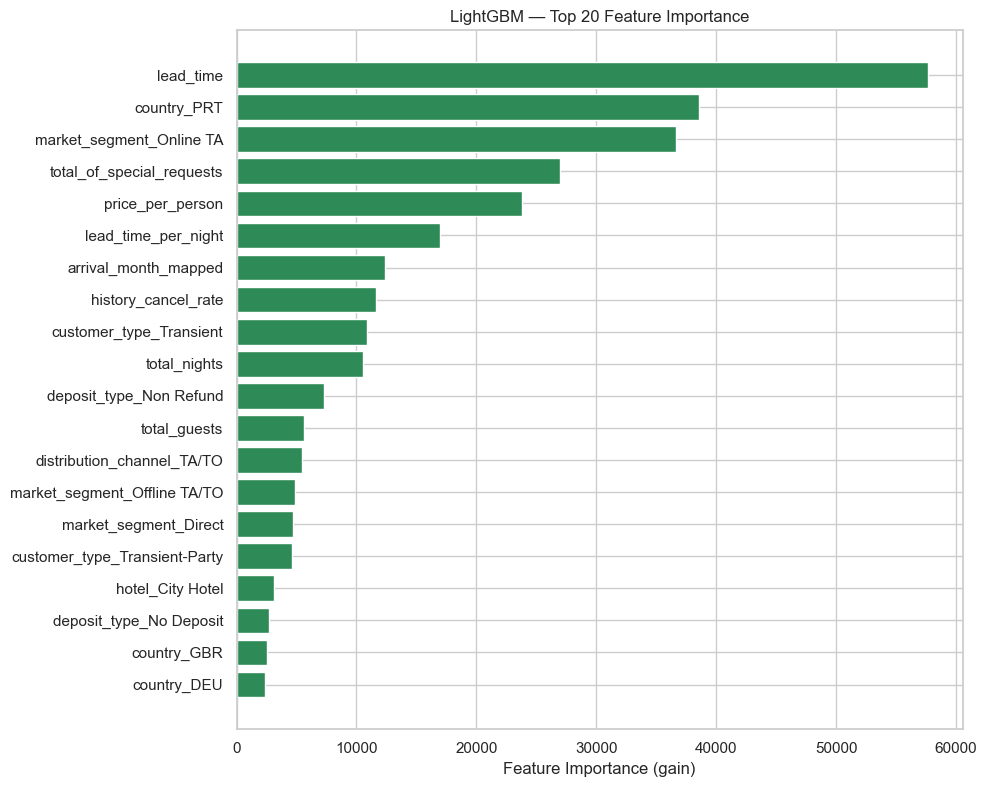


Tổng importance theo biến gốc:


,source,importance
1,country,58645.401117
9,lead_time,57672.018358
11,market,48269.541422
15,total_of_special_requests,26968.930098
12,price_per_person,23827.687776
2,customer,17171.085696
10,lead_time_per_night,16923.132770
0,arrival_month_mapped,12349.506858
5,history_cancel_rate,11634.050017
14,total_nights,10556.391034


In [41]:
preprocessor_fitted = lgbm_pipeline.named_steps["preprocessor"]
cat_encoder = preprocessor_fitted.named_transformers_["cat"]
cat_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = np.concatenate([cat_names, np.array(NUMERIC_FEATURES, dtype=object)])

classifier = lgbm_pipeline.named_steps["classifier"]
importances = classifier.booster_.feature_importance(importance_type="gain")

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Số cột sau One-Hot Encoding: {len(feature_names)}")
print("\nTop 20 feature quan trọng nhất (gain):")
display(importance_df.head(20))

top_n = 20
plot_df = importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["feature"], plot_df["importance"], color="seagreen")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title(f"LightGBM — Top {top_n} Feature Importance")
plt.tight_layout()
plt.show()

importance_df["source"] = importance_df["feature"].apply(
    lambda x: x if x in NUMERIC_FEATURES else x.split("_", 1)[0]
)
grouped = (
    importance_df.groupby("source", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)
print("\nTổng importance theo biến gốc:")
display(grouped)


## 8. Giải thích SHAP — Đóng góp biến engineered

Dùng **SHAP** (`TreeExplainer`) trên ma trận đã qua `ColumnTransformer`.

Lấy mẫu **2.000** booking từ tập test.


=== Mean |SHAP| — biến engineered (class Hủy) ===


,feature,mean_abs_shap,mean_shap,group
0,price_per_person,0.24435,-0.01170,Financial Commitment
1,lead_time_per_night,0.13853,0.00424,Trip Structure
2,arrival_month_mapped,0.13048,-0.00491,Calendar & Seasonality
3,history_cancel_rate,0.12136,0.01192,Trust & History
4,total_nights,0.11650,0.00975,Trip Structure
5,total_guests,0.09450,0.00294,Financial Commitment
6,is_family,0.02615,-0.00062,Financial Commitment
7,is_weekend_only,0.00195,-0.00016,Calendar & Seasonality



=== Tổng |SHAP| theo nhóm biến ===


,group,mean_abs_shap,mean_shap
1,Financial Commitment,0.36500,-0.00938
2,Trip Structure,0.25504,0.01400
0,Calendar & Seasonality,0.13243,-0.00506
3,Trust & History,0.12136,0.01192


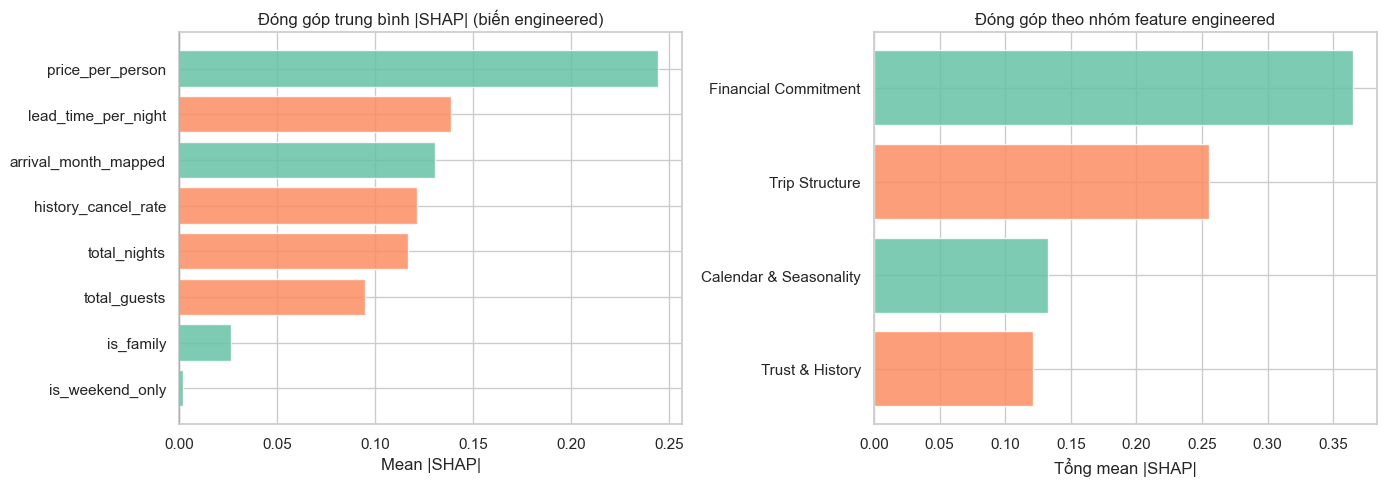

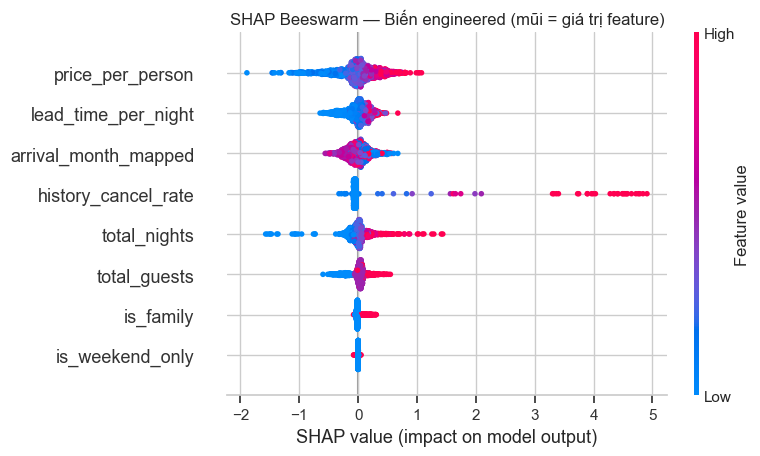

In [43]:
import shap

ENGINEERED_FEATURES = [
    "total_guests",
    "price_per_person",
    "is_family",
    "total_nights",
    "lead_time_per_night",
    "history_cancel_rate",
    "is_weekend_only",
    "arrival_month_mapped",
]
ENGINEERED_GROUPS = {
    "Financial Commitment": ["total_guests", "price_per_person", "is_family"],
    "Trip Structure": ["total_nights", "lead_time_per_night"],
    "Trust & History": ["history_cancel_rate"],
    "Calendar & Seasonality": ["is_weekend_only", "arrival_month_mapped"],
}
SHAP_SAMPLE_SIZE = 2_000

preprocessor_fitted = lgbm_pipeline.named_steps["preprocessor"]
classifier = lgbm_pipeline.named_steps["classifier"]

if "feature_names" not in globals():
    cat_encoder = preprocessor_fitted.named_transformers_["cat"]
    cat_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
    feature_names = np.concatenate([cat_names, np.array(NUMERIC_FEATURES, dtype=object)])

X_test_transformed = preprocessor_fitted.transform(X_test)
rng = np.random.default_rng(RANDOM_STATE)
n_shap = min(SHAP_SAMPLE_SIZE, len(X_test))
sample_idx = rng.choice(len(X_test), size=n_shap, replace=False)
X_shap_matrix = X_test_transformed[sample_idx]
y_shap = y_test.iloc[sample_idx].values

explainer = shap.TreeExplainer(classifier)
shap_all = explainer.shap_values(X_shap_matrix)
shap_values = shap_all[:, :, 1] if shap_all.ndim == 3 else shap_all

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]

sample_proba = classifier.predict_proba(X_shap_matrix)[:, 1]

eng_col_idx = [int(np.where(feature_names == f)[0][0]) for f in ENGINEERED_FEATURES]
shap_eng = shap_values[:, eng_col_idx]
X_eng = pd.DataFrame(X_shap_matrix[:, eng_col_idx], columns=ENGINEERED_FEATURES)

feature_to_group = {f: g for g, feats in ENGINEERED_GROUPS.items() for f in feats}

shap_eng_summary = (
    pd.DataFrame(
        {
            "feature": ENGINEERED_FEATURES,
            "mean_abs_shap": np.abs(shap_eng).mean(axis=0),
            "mean_shap": shap_eng.mean(axis=0),
        }
    )
    .assign(group=lambda d: d["feature"].map(feature_to_group))
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("=== Mean |SHAP| — biến engineered (class Hủy) ===")
display(shap_eng_summary.round(5))

group_shap = (
    shap_eng_summary.groupby("group", as_index=False)
    .agg(mean_abs_shap=("mean_abs_shap", "sum"), mean_shap=("mean_shap", "sum"))
    .sort_values("mean_abs_shap", ascending=False)
)
print("\n=== Tổng |SHAP| theo nhóm biến ===")
display(group_shap.round(5))

plot_df = shap_eng_summary.sort_values("mean_abs_shap", ascending=True)
colors = plot_df["mean_shap"].apply(lambda v: "#fc8d62" if v > 0 else "#66c2a5")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(plot_df["feature"], plot_df["mean_abs_shap"], color=colors, alpha=0.85)
axes[0].set_xlabel("Mean |SHAP|")
axes[0].set_title("Đóng góp trung bình |SHAP| (biến engineered)")
axes[0].axvline(0, color="black", linewidth=0.8)

group_plot = group_shap.sort_values("mean_abs_shap", ascending=True)
gcolors = group_plot["mean_shap"].apply(lambda v: "#fc8d62" if v > 0 else "#66c2a5")
axes[1].barh(group_plot["group"], group_plot["mean_abs_shap"], color=gcolors, alpha=0.85)
axes[1].set_xlabel("Tổng mean |SHAP|")
axes[1].set_title("Đóng góp theo nhóm feature engineered")
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_eng,
    X_eng,
    feature_names=ENGINEERED_FEATURES,
    plot_type="dot",
    show=False,
    max_display=len(ENGINEERED_FEATURES),
)
plt.title("SHAP Beeswarm — Biến engineered (mũi = giá trị feature)")
plt.tight_layout()
plt.show()


## 9. Tóm tắt v2

| Tiêu chí | RF v1.2 | **LightGBM v2** |
|----------|---------|-----------------|
| Thuật toán | `RandomForestClassifier` | **`LGBMClassifier`** |
| Feature | 16 (6 phân loại + 10 số) | **Giữ nguyên v1.2** |
| Tiền xử lý | One-Hot + passthrough | **Giữ nguyên** |
| Tuning | Không | **GridSearchCV + Optuna (mục 3b)** |
| Ngưỡng | 0,35 | **0,35** |

Chạy **Run All**; mục **3b** chọn `best_params`, mục **4** so sánh Baseline vs Tuned.
